<a href="https://colab.research.google.com/github/Rakesh-RMK/INTERNSHIP/blob/main/internship_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CODSOFT TASK 3
# IRIS FLOWER CLASSIFICATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")

print("Features:")
print(iris.feature_names)

print("\nTarget classes:")
print(iris.target_names)

print("\nDataset shape:")
print(X.shape)

Dataset loaded successfully!
Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


In [2]:
df_iris = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df_iris["Species"] = [
    iris.target_names[i]
    for i in y
]

display(df_iris.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Dataset Information:")
df_iris.info()

print("\nStatistical Summary:")
display(df_iris.describe())

print("\nMissing Values:")
print(df_iris.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


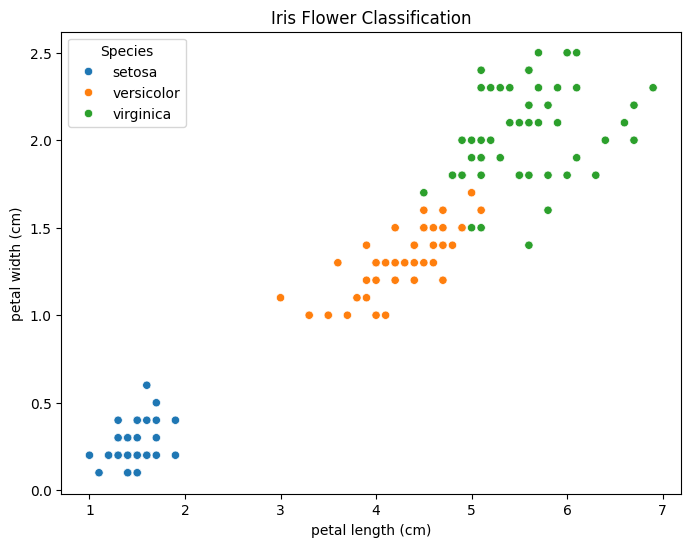

In [4]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_iris,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Species"
)

plt.title("Iris Flower Classification")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [6]:
from sklearn.ensemble import RandomForestClassifier

iris_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iris_model.fit(X_train, y_train)

print("Iris classification model trained successfully!")

Iris classification model trained successfully!


In [7]:
y_pred = iris_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]


In [8]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("====================================")
print("IRIS CLASSIFICATION RESULTS")
print("====================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

IRIS CLASSIFICATION RESULTS
Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



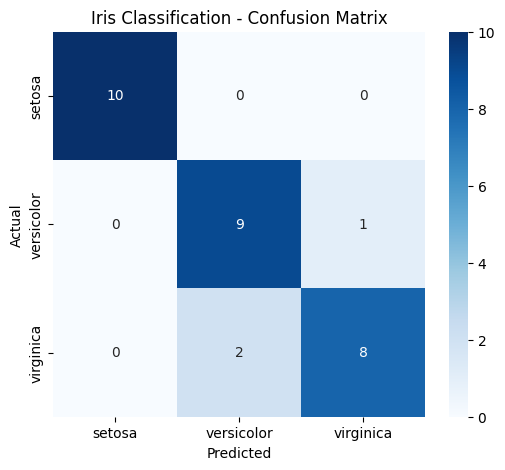

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iris Classification - Confusion Matrix")

plt.show()

In [10]:
# Example:
# Sepal Length = 5.1
# Sepal Width  = 3.5
# Petal Length = 1.4
# Petal Width  = 0.2

new_flower = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

prediction = iris_model.predict(new_flower)

predicted_species = iris.target_names[
    prediction[0]
]

print("====================================")
print("NEW FLOWER PREDICTION")
print("====================================")

print(
    "Predicted Species:",
    predicted_species
)

NEW FLOWER PREDICTION
Predicted Species: setosa
